# Hebbian model -- learning dynamics exploration

In [1]:
import pandas as pd
import numpy as np
from experimental_setups import hebbian_model, isc_model
import data
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from experimental_setups.hebbian_model import SimpleHebbianModel

In [ ]:
error_data = []
num_epochs = 10

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs, alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_experiment.csv')

Now training Hebbian model with alpha=0.05...
	...finished!
Now training Hebbian model with alpha=0.08...
	...finished!
Now training Hebbian model with alpha=0.12...
	...finished!
Now training Hebbian model with alpha=0.15...
	...finished!
Now training Hebbian model with alpha=0.18...
	...finished!
Now training Hebbian model with alpha=0.21...
	...finished!
Now training Hebbian model with alpha=0.25...
	...finished!
Now training Hebbian model with alpha=0.28...
	...finished!
Now training Hebbian model with alpha=0.31...
	...finished!
Now training Hebbian model with alpha=0.34...
	...finished!
Now training Hebbian model with alpha=0.38...
	...finished!
Now training Hebbian model with alpha=0.41...
	...finished!
Now training Hebbian model with alpha=0.44...
	...finished!
Now training Hebbian model with alpha=0.48...
	...finished!
Now training Hebbian model with alpha=0.51...
	...finished!
Now training Hebbian model with alpha=0.54...
	...finished!
Now training Hebbian model with alpha=0.

In [25]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

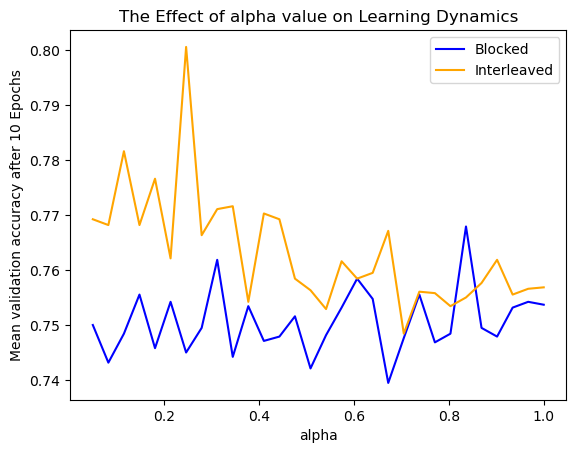

In [26]:
import matplotlib.pyplot as plt

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in np.linspace(0.05,1,30):
    errs_alpha_blocked = error_data
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['alpha']==alpha]
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['condition']=='blocked']
    errs_alpha_blocked = errs_alpha_blocked['acc'].mean()

    errs_alpha_interleaved = error_data
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==alpha]
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
    errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(np.linspace(0.05,1,30), mean_accs_blocked, color='blue', label='Blocked')
plt.plot(np.linspace(0.05,1,30), mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()

In [ ]:
error_data = pd.read_csv('data/hebbian_alpha_experiment_n40.csv')
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

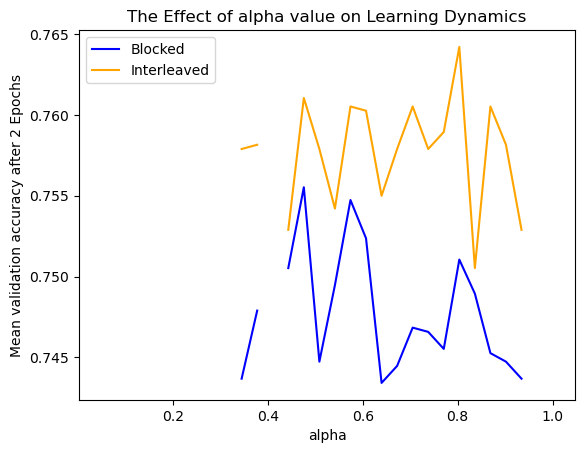

In [ ]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()
import matplotlib.pyplot as plt

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in np.linspace(0.05,1,30):
    errs_alpha_blocked = error_data
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['alpha']==alpha]
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['condition']=='blocked']
    errs_alpha_blocked = errs_alpha_blocked['acc'].mean()

    errs_alpha_interleaved = error_data
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==alpha]
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
    errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(np.linspace(0.05,1,30), mean_accs_blocked, color='blue', label='Blocked')
plt.plot(np.linspace(0.05,1,30), mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()

What if we move the Oja weight updates to the task CCD layer?

In [25]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_taskcd.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [27]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

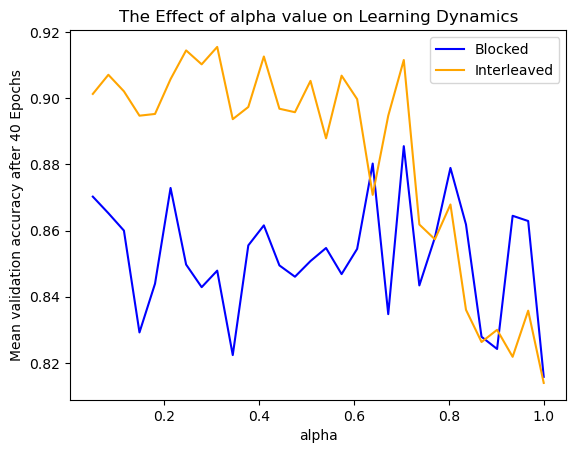

In [28]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()
import matplotlib.pyplot as plt

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in np.linspace(0.05,1,30):
    errs_alpha_blocked = error_data
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['alpha']==alpha]
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['condition']=='blocked']
    errs_alpha_blocked = errs_alpha_blocked['acc'].mean()

    errs_alpha_interleaved = error_data
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==alpha]
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
    errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(np.linspace(0.05,1,30), mean_accs_blocked, color='blue', label='Blocked')
plt.plot(np.linspace(0.05,1,30), mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()

Let's do online learning -- batch size of 1!

In [8]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha, batch_size=1)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_online.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [9]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

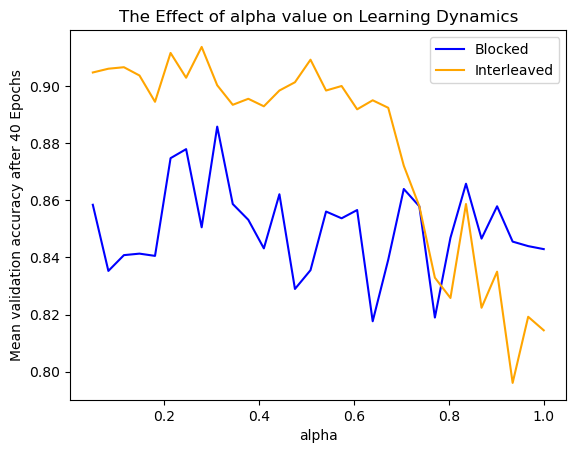

In [10]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()
import matplotlib.pyplot as plt

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in np.linspace(0.05,1,30):
    errs_alpha_blocked = error_data
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['alpha']==alpha]
    errs_alpha_blocked = errs_alpha_blocked[errs_alpha_blocked['condition']=='blocked']
    errs_alpha_blocked = errs_alpha_blocked['acc'].mean()

    errs_alpha_interleaved = error_data
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==alpha]
    errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
    errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(np.linspace(0.05,1,30), mean_accs_blocked, color='blue', label='Blocked')
plt.plot(np.linspace(0.05,1,30), mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()

## Oja's rule exploration

Is Oja's rule working as expected to orthogonalize the representations here?

In [10]:
oja_test = OjaMiniModel(lr=1e-3)

device = torch.device("mps")

oja_test.to(device)

train_x,train_y,_,_,_,_ = data.make_behavioral_experiment_training_data(distractor_strength=.975)

# filter data to always contain category context
train_x = train_x[1][:20*19]
oja_test.train(train_x)

Cosine similarity: 0.08271816372871399
Weight norm: 0.022220440208911896
Cosine sim with context direction: 0.16849982738494873
Cosine similarity: 0.07908198237419128
Weight norm: 0.022167906165122986
Cosine sim with context direction: 0.1596967577934265
Cosine similarity: 0.07504472881555557
Weight norm: 0.022208981215953827
Cosine sim with context direction: 0.15010502934455872
Cosine similarity: 0.07051140815019608
Weight norm: 0.02234504744410515
Cosine sim with context direction: 0.14000214636325836
Cosine similarity: 0.06594681739807129
Weight norm: 0.02258060686290264
Cosine sim with context direction: 0.12905949354171753
Cosine similarity: 0.061179596930742264
Weight norm: 0.022917652502655983
Cosine sim with context direction: 0.11770262569189072
Cosine similarity: 0.056305937469005585
Weight norm: 0.023352552205324173
Cosine sim with context direction: 0.10605538636445999
Cosine similarity: 0.051459334790706635
Weight norm: 0.02388307824730873
Cosine sim with context directio

In [41]:
len(torch.unique(train_x, dim=0))

2

## New Oja-based model

In [2]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_new_setup.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [5]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

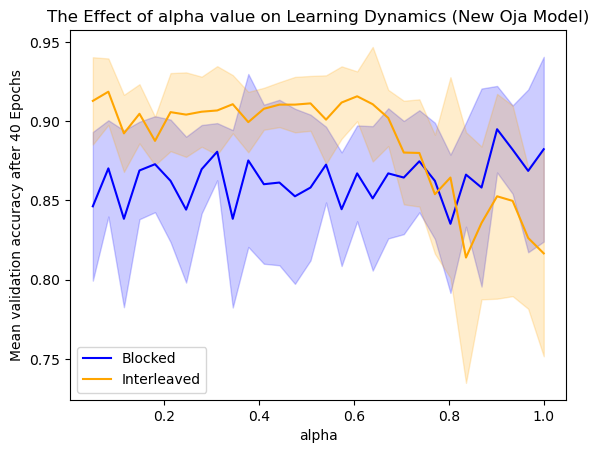

In [9]:
import matplotlib.pyplot as plt

alphas = np.linspace(0.05, 1, 30)
mean_accs_blocked, std_accs_blocked = [], []
mean_accs_interleaved, std_accs_interleaved = [], []

for alpha in alphas:
    for condition, mean_list, std_list in [
        ('blocked', mean_accs_blocked, std_accs_blocked),
        ('interleaved', mean_accs_interleaved, std_accs_interleaved),
    ]:
        subset = error_data[(error_data['alpha'] == alpha) & (error_data['condition'] == condition)]
        per_model = subset.groupby('model')['acc'].mean()
        mean_list.append(per_model.mean())
        std_list.append(per_model.std())

mean_accs_blocked = np.array(mean_accs_blocked)
std_accs_blocked = np.array(std_accs_blocked)
mean_accs_interleaved = np.array(mean_accs_interleaved)
std_accs_interleaved = np.array(std_accs_interleaved)

plt.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
plt.fill_between(alphas, mean_accs_blocked - std_accs_blocked, mean_accs_blocked + std_accs_blocked,
                 alpha=0.2, color='blue')

plt.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')
plt.fill_between(alphas, mean_accs_interleaved - std_accs_interleaved, mean_accs_interleaved + std_accs_interleaved,
                 alpha=0.2, color='orange')

plt.title('The Effect of alpha value on Learning Dynamics (New Oja Model)')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')
plt.savefig('images/ema/alpha_grid_search')
plt.show()